In [1]:
import pandas as pd

In [2]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results.csv')

In [3]:
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [4]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/basemodel_results.csv')
base_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [5]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('Base Model Similarity:', base_model['similarity_score'].mean())

Base Model Similarity: 0.4948666666666666


In [6]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('New Model Similarity:', new_model['similarity_score'].mean())

New Model Similarity: 0.7417333333333332


In [7]:
base_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
149,150,Compute count of rows grouped by models. \nCol...,df.groupby('models').size(),data = {'INIT_DATE_TIME': ['2023-04-01 10:00:0...,0.06,False,False,NaN
17,18,Compute count of rows grouped by models. \nCol...,df.groupby('models').size(),data = {'INIT_DATE_TIME': ['2023-04-01 10:00:0...,0.06,False,False,NaN
51,52,Compute count of rows grouped by models. \nCol...,df.groupby('LZ').size(),data = {'INIT_DATE_TIME': ['2023-04-01 10:00:0...,0.06,False,False,NaN
97,98,Count unique values of day_ahead. \nColumns: I...,df['power_OBS'].nunique(),data = {'INIT_DATE_TIME': ['2023-04-01 08:00:0...,0.08,False,False,NaN
122,123,Get unique values of gain. \nColumns: INIT_DAT...,df['gain'].unique(),"data = {'INIT_DATE_TIME': ['2023-04-01 10:00',...",0.09,False,False,NaN
...,...,...,...,...,...,...,...,...
109,110,Filter rows where pred is equal to1.0. \nColum...,df[df['pred'] == 195.0],df[(df['pred'] == 1.0)],0.91,True,True,NaN
131,132,Return top 123.0 rows by gain. \nColumns: INIT...,"df.nlargest(174.0, 'gain')","df.nlargest(123.0, 'gain')",0.92,True,True,NaN
27,28,Sort the DataFrame by gain. \nColumns: INIT_DA...,df.sort_values('gain'),df.sort_values(by='gain'),0.94,True,True,NaN
88,89,Sort the DataFrame by day_ahead. \nColumns: IN...,df.sort_values('day_ahead'),df.sort_values(by='day_ahead'),0.95,True,True,NaN


In [8]:
new_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
64,65,Compute the mean and std of day_ahead grouped ...,"df.groupby('LZ')['pred'].agg(['mean','std'])","""""",0.00,False,False,NaN
57,58,Compute the mean and std of day_ahead grouped ...,"df.groupby('LZ')['day_ahead'].agg(['mean','std'])","""""",0.00,False,False,NaN
141,142,Return bottom 166.0 rows by power_OBS. \nColum...,"df.nsmallest(62.0, 'day_ahead')",df.loc[df['power_OBS'].str.contains('bottom')]...,0.18,False,False,NaN
115,116,Return top 93.0 rows by day_ahead. \nColumns: ...,"df.nlargest(20.0, 'power_OBS')","df.loc[df['day_ahead'].rank(method='dense', as...",0.21,False,False,NaN
136,137,Return bottom 162.0 rows by gain. \nColumns: I...,"df.nsmallest(70.0, 'power_OBS')",df.loc[df['gain'].tail(162).index],0.22,False,False,NaN
...,...,...,...,...,...,...,...,...
73,74,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
49,50,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
34,35,Compute the min of pred grouped by models. \nC...,df.groupby('models')['pred'].min(),df.groupby('models')['pred'].min(),1.00,True,True,NaN
32,33,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN


In [9]:
num = 142

In [10]:
print(new_model[new_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(new_model[new_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(new_model[new_model['test_case_id'] == num]['generated_output'].values[0])

Return bottom 166.0 rows by power_OBS. 
Columns: INIT_DATE_TIME, LZ, models, power_OBS, day_ahead, pred, gain
------------------
df.nsmallest(62.0, 'day_ahead')
-----
df.loc[df['power_OBS'].str.contains('bottom')].tail(166)


In [11]:
print(base_model[base_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(base_model[base_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(base_model[base_model['test_case_id'] == num]['generated_output'].values[0])

Return bottom 166.0 rows by power_OBS. 
Columns: INIT_DATE_TIME, LZ, models, power_OBS, day_ahead, pred, gain
------------------
df.nsmallest(62.0, 'day_ahead')
-----
df.loc[df['power_OBS'].str.contains('bottom 166.0')]


In [12]:
new_model[new_model['similarity_score'] > .85]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
39,40,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
12,13,Compute the sum of pred grouped by LZ. \nColum...,df.groupby('LZ')['pred'].sum(),df.groupby('LZ')['pred'].sum(),1.00,True,True,NaN
130,131,Compute the max of power_OBS grouped by models...,df.groupby('models')['power_OBS'].max(),df.groupby('models')['power_OBS'].max(),1.00,True,True,NaN
71,72,Get unique values of gain. \nColumns: INIT_DAT...,df['gain'].unique(),df['gain'].unique(),1.00,True,True,NaN
114,115,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
142,143,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
119,120,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
145,146,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
120,121,Compute the min of pred grouped by LZ. \nColum...,df.groupby('LZ')['pred'].min(),df.groupby('LZ')['pred'].min(),1.00,True,True,NaN
32,33,Filter rows where gain is negative. \nColumns:...,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN


In [13]:
print('New Model:', new_model["is_correct"].mean().round(4))
print('Base Model:', base_model["is_correct"].mean().round(4))

New Model: 0.26
Base Model: 0.04


In [14]:
print('New Model:', new_model["method_correct"].mean().round(4))
print('Base Model:', base_model["method_correct"].mean().round(4))

New Model: 0.6667
Base Model: 0.2467


In [15]:
print('New Model:', new_model.loc[~new_model["is_correct"], "similarity_score"].mean())
print('Base Model:', base_model.loc[~base_model["is_correct"], "similarity_score"].mean())

New Model: 0.663873873873874
Base Model: 0.47638888888888886


In [16]:
print('New Model:', new_model.loc[~new_model["method_correct"], "similarity_score"].mean())
print('Base Model:', base_model.loc[~base_model["method_correct"], "similarity_score"].mean())

New Model: 0.5162
Base Model: 0.3951327433628319


In [17]:
near_miss_rate = (
    (new_model["similarity_score"] >= 0.8) &
    (new_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.10666666666666667)

In [18]:
near_miss_rate = (
    (base_model["similarity_score"] >= 0.8) &
    (base_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.05333333333333334)

In [19]:
print('New Model:', (new_model["similarity_score"] < 0.7).mean())
print('Base Model:', (base_model["similarity_score"] < 0.7).mean())

New Model: 0.30666666666666664
Base Model: 0.7533333333333333


In [20]:
new_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Count,0.000000,0.700000,3
Extract,0.000000,0.480000,6
Return,0.062500,0.398125,16
Compute,0.187500,0.791250,48
Sort,0.222222,0.771111,9
Get,0.300000,0.814000,10
Filter,0.413793,0.807759,58


In [21]:
base_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Compute,0.000000,0.441875,48
Count,0.000000,0.243333,3
Extract,0.000000,0.350000,6
Filter,0.034483,0.571897,58
Return,0.062500,0.343125,16
Get,0.100000,0.459000,10
Sort,0.222222,0.771111,9


In [22]:
final_score = (
    0.3 * new_model["is_correct"].mean() +
    0.4 * new_model["method_correct"].mean() +
    0.3 * new_model["similarity_score"].mean()
)

final_score

np.float64(0.5671866666666666)

In [23]:
final_score = (
    0.3 * base_model["is_correct"].mean() +
    0.4 * base_model["method_correct"].mean() +
    0.3 * base_model["similarity_score"].mean()
)

final_score

np.float64(0.25912666666666667)

In [25]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = base_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

In [26]:
# from scipy.stats import ttest_rel

# t_stat, p_value = ttest_rel(
#     new2["similarity_score"],
#     base2["similarity_score"]
# )

# t_stat, p_value

In [27]:

# import numpy as np
# diff = new2["similarity_score"] - base2["similarity_score"]

# boot_means = []
# rng = np.random.default_rng(42)

# for _ in range(10000):
#     sample = rng.choice(diff, size=len(diff), replace=True)
#     boot_means.append(sample.mean())

# ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
# mean_diff = diff.mean()

# mean_diff, ci_low, ci_high

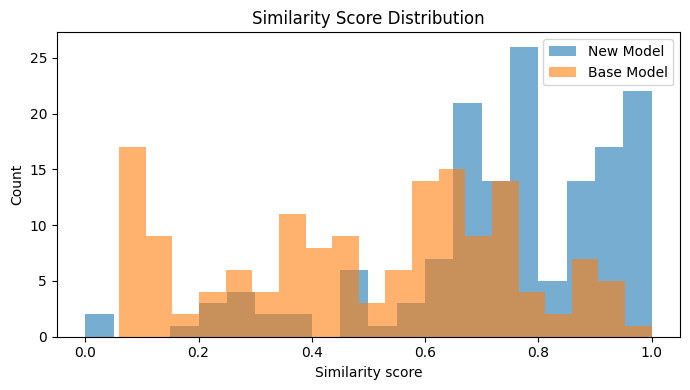

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Base Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

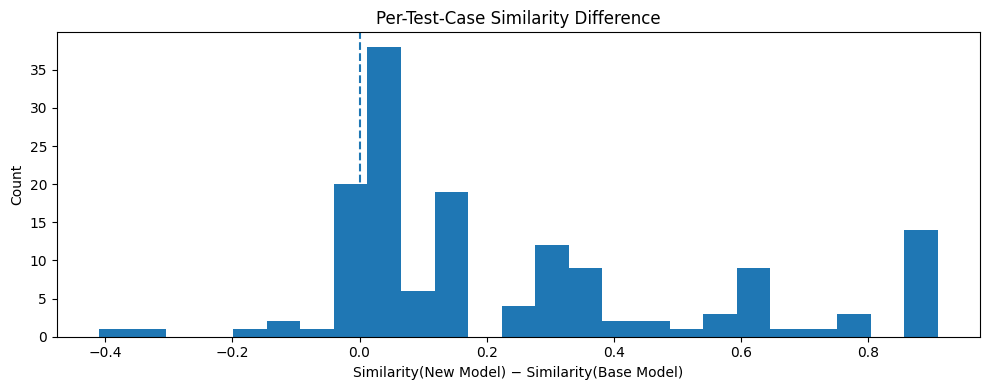

In [29]:
diff = new2["similarity_score"] - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.hist(diff, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Similarity(New Model) − Similarity(Base Model)")
plt.ylabel("Count")
plt.title("Per-Test-Case Similarity Difference")
plt.tight_layout()
plt.show()

In [30]:
new2

,test_case_id,is_correct,similarity_score,method_correct
0,1,False,0.87,True
1,2,False,0.67,False
2,3,True,0.96,True
3,4,True,0.94,True
4,5,False,0.77,True
...,...,...,...,...
145,146,True,1.00,True
146,147,True,0.91,True
147,148,False,0.85,True
148,149,False,0.78,True


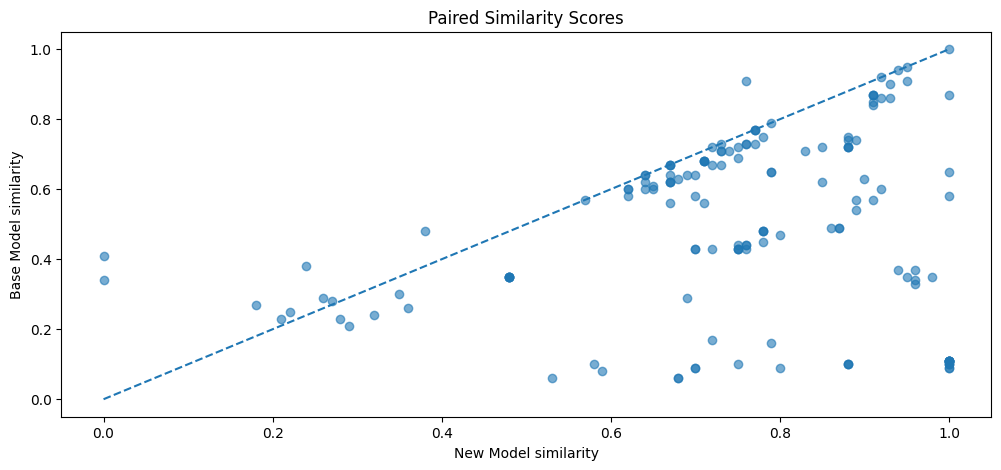

In [32]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= base2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Base Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

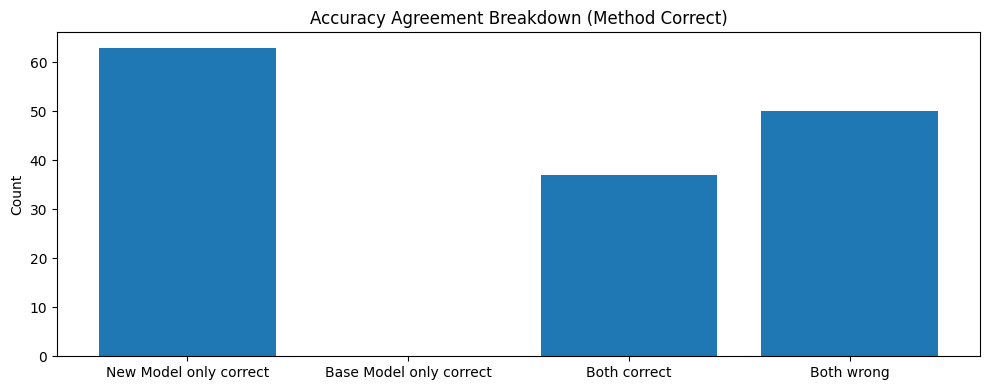

In [33]:
a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
both = ((new2.method_correct) & (base2.method_correct)).sum()
neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

plt.figure(figsize=(10,4))
plt.bar(
    ["New Model only correct", "Base Model only correct", "Both correct", "Both wrong"],
    [a_only, b_only, both, neither]
)
plt.ylabel("Count")
plt.title("Accuracy Agreement Breakdown (Method Correct)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48049/2770892061.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base], labels=["New Model", "Base Model"])


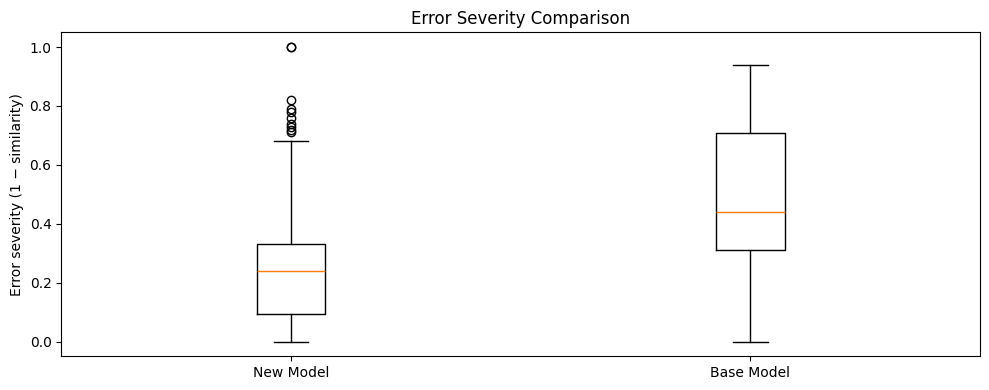

In [34]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base], labels=["New Model", "Base Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison")
plt.tight_layout()
plt.show()

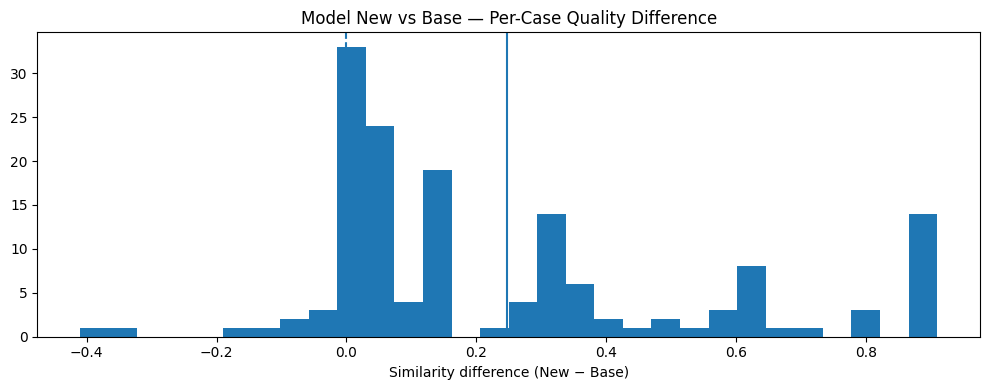

In [35]:
plt.figure(figsize=(10,4))
plt.hist(diff, bins=30)
plt.axvline(0, linestyle="--")
plt.axvline(diff.mean())
plt.title("Model New vs Base — Per-Case Quality Difference")
plt.xlabel("Similarity difference (New − Base)")
plt.tight_layout()
plt.show()

In [36]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

base_model["task_type"] = (
    base_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

In [37]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.480000,1.000000,0.520000,6
other,0.137931,0.572759,0.862069,0.427241,29
compute,0.187500,0.791250,0.812500,0.208750,48
sort,0.222222,0.771111,0.777778,0.228889,9
filter,0.413793,0.807759,0.586207,0.192241,58


In [38]:
task_stats_base = (
    base_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.000000,0.441875,1.000000,0.558125,48
extract,0.000000,0.350000,1.000000,0.650000,6
filter,0.034483,0.571897,0.965517,0.428103,58
other,0.068966,0.372759,0.931034,0.627241,29
sort,0.222222,0.771111,0.777778,0.228889,9


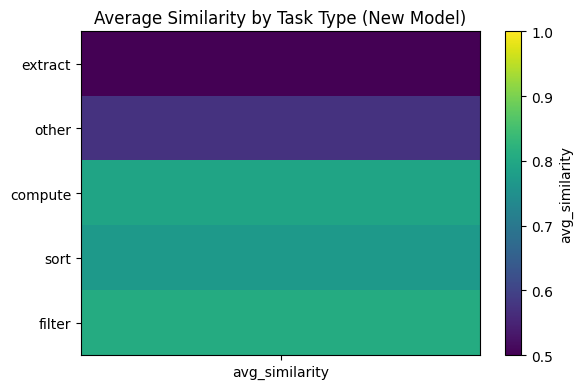

In [39]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_new[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_new)), task_stats_new.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (New Model)")
plt.tight_layout()
plt.show()

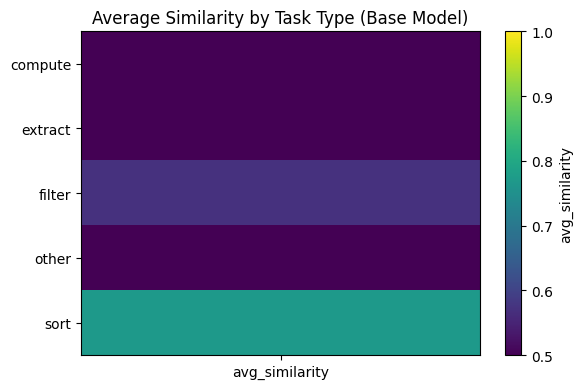

In [40]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_base[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_base)), task_stats_base.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (Base Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48049/295813842.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  new_model.pivot_table(


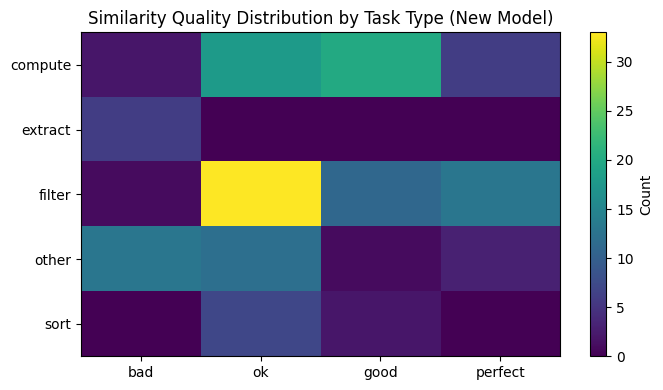

In [41]:
new_model["sim_bin"] = pd.cut(
    new_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    new_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_48049/2786547845.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  base_model.pivot_table(


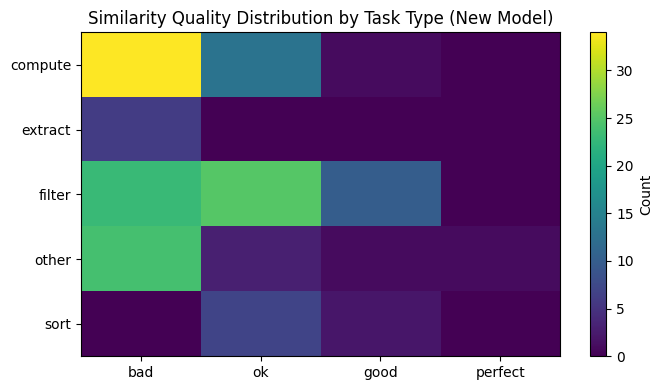

In [42]:
base_model["sim_bin"] = pd.cut(
    base_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    base_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

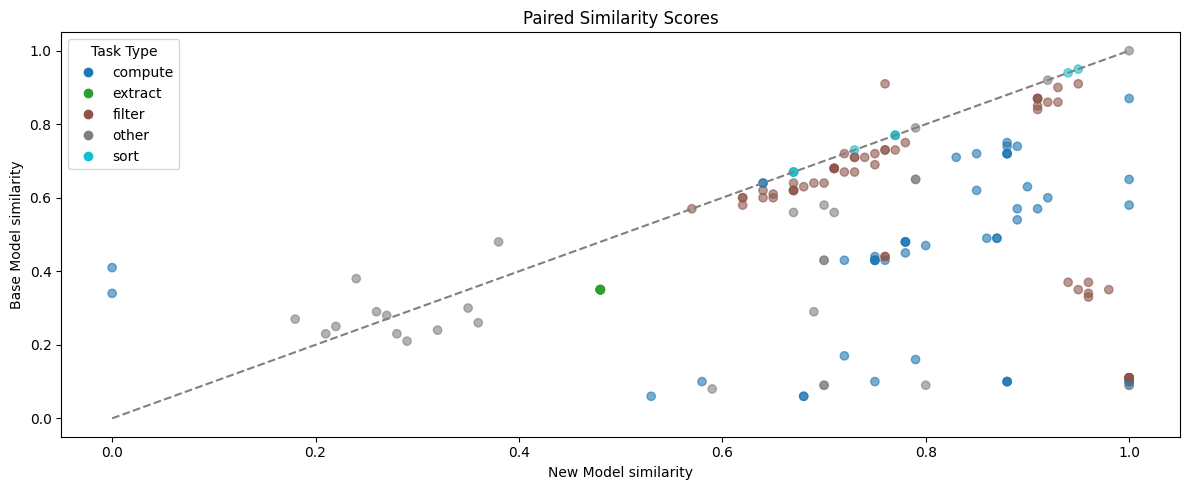

In [50]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = base_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Base Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()